# Green's Functions: Resolvent Response Solver

This notebook computes a finite-system Green's function response. For a Hamiltonian `H`, the retarded Green's function is `(omega + i eta - H)^-1`. The imaginary part of a matrix element gives a broadened spectral response.

## Notebook guide

- **Learning objective:** approximate a resolvent and validate its response function.
- **Prerequisites:** an editable repository install, the relevant tutorial workflow, and basic spectral linear algebra.
- **Estimated runtime:** about 1–3 minutes on a local CPU.
- **Navigation:** [collection index](README.md) · [previous](02_hamiltonian_simulation_schrodinger_dynamics.ipynb) · [next](04_ising_phase_transition_filtering.ipynb).


## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a tight-binding local Green's-function response problem.

**QSVT implementation.** It approximates resolvent components with polynomial matrix functions. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Direct complex resolvent evaluation is the classical reference. Resolvent estimation is a natural QSVT target for large Hamiltonians where selected response functions are needed without constructing the full inverse.


## Variable definitions

- $H$ is the tight-binding Hamiltonian, $\omega$ is frequency, $\eta>0$ is the broadening, and $i=\sqrt{-1}$.
- $G(\omega)=(\omega+i\eta-H)^{-1}$ is the retarded Green's function.
- $|p\rangle$ is the local probe state, and $-\operatorname{Im}\langle p|G(\omega)|p\rangle$ is the sampled response.
- With spectral scale $s$, $A=H/s$ is the normalized Hamiltonian used by the polynomial approximation.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian
from qsvt.hamiltonians import tight_binding_chain
from qsvt.design import design_resolvent_polynomials

H = tight_binding_chain(5)
probe = np.zeros(5)
probe[2] = 1.0
eta = 0.35
omegas = np.linspace(-2.2, 2.2, 120)
evals, _ = eigh_hermitian(H)
scale = np.max(np.abs(evals))
A = H / scale

exact_response = []
poly_response = []
for omega in omegas:
    exact_G = np.linalg.inv((omega + 1j * eta) * np.eye(5) - H)
    exact_response.append(-np.imag(np.vdot(probe, exact_G @ probe)) / np.pi)

    _, imag_coeffs = design_resolvent_polynomials(
        omega=omega, eta=eta, scale=scale, degree=34
    )
    imag_G = apply_polynomial_to_hermitian(A, imag_coeffs)
    poly_response.append(-np.vdot(probe, imag_G @ probe).real / np.pi)

response_error = np.linalg.norm(
    np.array(poly_response) - np.array(exact_response)
) / np.linalg.norm(exact_response)
print(f"Response Error: {response_error}")

Response Error: 0.0012364154973827407


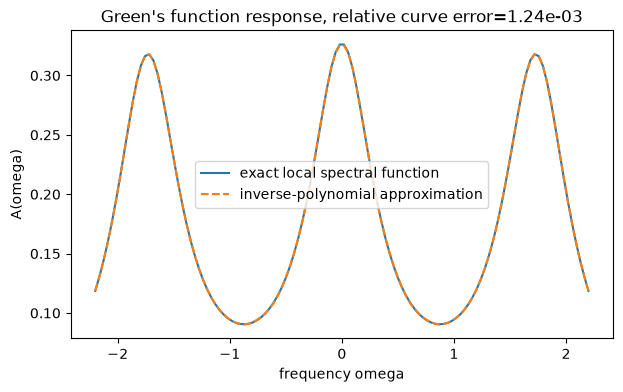

In [2]:
plt.figure(figsize=(7, 4))
plt.plot(omegas, exact_response, label="exact local spectral function")
plt.plot(omegas, poly_response, "--", label="inverse-polynomial approximation")
plt.xlabel("frequency omega")
plt.ylabel("A(omega)")
plt.title(f"Green's function response, relative curve error={response_error:.2e}")
plt.legend()
plt.show()

## Takeaways and next steps

- **Result:** The workflow shows how to approximate a resolvent and validate its response function.
- **Interpretation boundary:** This is a finite, simulator-scale application client; input, readout, and scalability assumptions remain explicit.
- **Continue:** [collection index](README.md) · [previous](02_hamiltonian_simulation_schrodinger_dynamics.ipynb) · [next](04_ising_phase_transition_filtering.ipynb).
